03 - Forecasting Models

01. Import Libraries
02. Load Train / Test
03. Train-Test Date Check
04. Target & Feature Selection
05. EWM Features
06. Missing Value Check
07. Categorical Features
08. Baseline 1 → Naive
09. Baseline 2 → Moving Average
10. Baseline 3 → EWM
11. Evaluation Metrics
12. Time-Based Validation
13. XGBoost
14. LightGBM
15. XGBoost vs LightGBM
16. Log Target Experiment
17. Hyperparameter Tuning
18. Feature Importance
19. Error Analysis
20. Final Model Selection
21. Final Test Evaluation
22. Future Demand Forecast
23. Forecast Output

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:

#Load Train / test
train = pd.read_csv("train-2.csv")
test = pd.read_csv("test-2.csv")

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain date:")
print(train["Date"].min(), "->", train["Date"].max())

print("\nTest date:")
print(test["Date"].min(), "->", test["Date"].max())

Train shape: (66900, 38)
Test shape: (3200, 38)

Train date:
2022-01-01 00:00:00 -> 2023-10-31 00:00:00

Test date:
2023-12-01 00:00:00 -> 2024-01-01 00:00:00


In [4]:
#Train-Test Date Check / Sort

train = train.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

test = test.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

In [5]:
# Target & Feature Selection

target = "Units Sold"

y_train = train[target]
y_test = test[target]

In [6]:
print(y_train.describe())

count    66900.000000
mean       136.435575
std        109.020346
min          0.000000
25%         48.000000
50%        107.000000
75%        202.000000
max        499.000000
Name: Units Sold, dtype: float64


In [7]:
print(train.columns.tolist())

['Date', 'Store ID', 'Product ID', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Holiday/Promotion', 'Year', 'Month', 'Day', 'DayOfWeek', 'NET_PRICE', 'Price_Diff', 'Price_Ratio', 'units_sold_lag_1', 'units_sold_lag_2', 'units_sold_lag_3', 'units_sold_lag_7', 'units_sold_lag_14', 'units_sold_lag_30', 'units_sold_lag_365', 'sales_roll_mean_7', 'sales_roll_mean_30', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Region_North', 'Region_South', 'Region_West', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_NEW_Spring', 'Seasonality_NEW_Summer', 'Seasonality_NEW_Winter']


In [8]:
# EWM Features
#EWM 7 & 30

all_data = pd.concat(
    [train, test],
    ignore_index=True
)

all_data = all_data.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

all_data["sales_ewm_7"] = (
    all_data
    .groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(
        lambda x: x.shift(1).ewm(
            span=7,
            adjust=False
        ).mean()
    )
)

all_data["sales_ewm_30"] = (
    all_data
    .groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(
        lambda x: x.shift(1).ewm(
            span=30,
            adjust=False
        ).mean()
    )
)

train_end_date = train["Date"].max()

train = all_data[
    all_data["Date"] <= train_end_date
].copy()

test = all_data[
    all_data["Date"] > train_end_date
].copy()

In [9]:
# EWM kontrol
train[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Units Sold",
        "sales_ewm_7",
        "sales_ewm_30"
    ]
].head(15)

,Date,Store ID,Product ID,Units Sold,sales_ewm_7,sales_ewm_30
0,2022-01-01,S001,P0001,127,NaN,NaN
1,2022-01-02,S001,P0001,81,127.000000,127.000000
2,2022-01-03,S001,P0001,5,115.500000,124.032258
3,2022-01-04,S001,P0001,58,87.875000,116.352758
4,2022-01-05,S001,P0001,147,80.406250,112.588064
5,2022-01-06,S001,P0001,37,97.054688,114.808188
6,2022-01-07,S001,P0001,107,82.041016,109.788305
7,2022-01-08,S001,P0001,2,88.280762,109.608415
8,2022-01-09,S001,P0001,350,66.710571,102.665936
9,2022-01-10,S001,P0001,36,137.532928,118.622973


In [10]:
drop_cols = [
    "Units Sold",
    "Date",
    "Units Ordered"  # Sızıntıyı (leakage) engellemek için eklendi
]

for maybe_leak in ["Demand Forecast", "Demand_Forecast_Baseline",
                    "Store ID_Code", "Product ID_Code", "Category_Code"]:
    if maybe_leak in train.columns:
        drop_cols.append(maybe_leak)

print("drop_cols:", drop_cols)

drop_cols: ['Units Sold', 'Date', 'Units Ordered']


In [11]:
X_train = train.drop(columns=drop_cols)
y_train = train["Units Sold"]

X_test = test.drop(columns=drop_cols)
y_test = test["Units Sold"]

print(X_train.dtypes)

Store ID                       str
Product ID                     str
Inventory Level              int64
Price                      float64
Discount                     int64
Holiday/Promotion            int64
Year                         int64
Month                        int64
Day                          int64
DayOfWeek                    int64
NET_PRICE                  float64
Price_Diff                 float64
Price_Ratio                float64
units_sold_lag_1           float64
units_sold_lag_2           float64
units_sold_lag_3           float64
units_sold_lag_7           float64
units_sold_lag_14          float64
units_sold_lag_30          float64
units_sold_lag_365         float64
sales_roll_mean_7          float64
sales_roll_mean_30         float64
Category_Electronics         int64
Category_Furniture           int64
Category_Groceries           int64
Category_Toys                int64
Region_North                 int64
Region_South                 int64
Region_West         

In [12]:

categorical_cols = [
    c for c in X_train.columns
    if pd.api.types.is_string_dtype(X_train[c])
    or isinstance(X_train[c].dtype, pd.CategoricalDtype)
]
print("categorical_cols:", categorical_cols)

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

X_train.dtypes.value_counts()

categorical_cols: ['Store ID', 'Product ID']


int64       20
float64     15
category     1
category     1
Name: count, dtype: int64

In [13]:
# Baseline modelleri train verisi üzerinde hesaplama
val_baseline = train.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

# 1. Naive (Önceki günün satışı)
val_baseline["naive_prediction"] = (
    val_baseline.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
)

# 2. 7 Günlük Hareketli Ortalama
val_baseline["ma_7_prediction"] = (
    val_baseline.groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# 3. 7 Günlük Üstel Ağırlıklı Ortalama (EWM)
val_baseline["ewm_7_prediction"] = (
    val_baseline.groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
)

# Yalnızca validation dönemini (son 30 günü) filtreleme
# Not: validation_start değişkeni 16. hücrede tanımlanıyor; 
# bu hücre 16. hücreden sonra çalıştırılmalı veya validation_start burada hesaplanmalı:
val_start_date = train["Date"].max() - pd.Timedelta(days=30 - 1)
val_baseline_eval = val_baseline[val_baseline["Date"] >= val_start_date].copy()

print("Validation Baseline Shape:", val_baseline_eval.shape)
val_baseline_eval[["naive_prediction", "ma_7_prediction", "ewm_7_prediction"]].isna().mean()

Validation Baseline Shape: (3000, 43)


naive_prediction    0.0
ma_7_prediction     0.0
ewm_7_prediction    0.0
dtype: float64

In [14]:
def mae(y_true, y_pred):
    return mean_absolute_error(
        y_true,
        y_pred
    )

def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    )
    return np.mean(
        2 * np.abs(y_true - y_pred) /
        np.where(denominator == 0, 1, denominator)
    ) * 100

def wape(y_true, y_pred):
    return (
        np.sum(
            np.abs(y_true - y_pred)
        )
        /
        np.sum(
            np.abs(y_true)
        )
    ) * 100

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [15]:
# Naive Evaluation (Validation üzerinde)
naive_eval = val_baseline_eval.dropna(subset=["naive_prediction"])
naive_results = evaluate_model(
    naive_eval["Units Sold"],
    naive_eval["naive_prediction"]
)

# Moving Average 7 Evaluation (Validation üzerinde)
ma_eval = val_baseline_eval.dropna(subset=["ma_7_prediction"])
ma_results = evaluate_model(
    ma_eval["Units Sold"],
    ma_eval["ma_7_prediction"]
)

# EWM 7 Evaluation (Validation üzerinde)
ewm_eval = val_baseline_eval.dropna(subset=["ewm_7_prediction"])
ewm_results = evaluate_model(
    ewm_eval["Units Sold"],
    ewm_eval["ewm_7_prediction"]
)

baseline_results = pd.DataFrame({
    "Naive": naive_results,
    "Moving Average 7": ma_results,
    "EWM 7": ewm_results
}).T

baseline_results

,MAE,RMSE,sMAPE,WAPE,R2
Naive,119.925333,153.795774,92.584841,87.444402,-0.996421
Moving Average 7,93.197238,115.934272,73.511822,67.955423,-0.134454
EWM 7,93.265247,116.173594,73.454158,68.005012,-0.139143


In [16]:
validation_days = 30

validation_start = (
    train["Date"].max()
    - pd.Timedelta(days=validation_days - 1)
)

train_model = train[
    train["Date"] < validation_start
].copy()

validation = train[
    train["Date"] >= validation_start
].copy()

print("Model train:")
print(train_model["Date"].min(), "->", train_model["Date"].max())

print("\nValidation:")
print(validation["Date"].min(), "->", validation["Date"].max())

Model train:
2022-01-01 00:00:00 -> 2023-10-01 00:00:00

Validation:
2023-10-02 00:00:00 -> 2023-10-31 00:00:00


In [17]:
X_tr = train_model.drop(
    columns=drop_cols
)
y_tr = train_model[target]

X_val = validation.drop(
    columns=drop_cols
)
y_val = validation[target]

for col in categorical_cols:
    X_tr[col] = X_tr[col].astype("category")
    X_val[col] = X_val[col].astype("category")

In [18]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=50  
)

In [19]:
xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

In [20]:
xgb_val_pred = xgb_model.predict(X_val)

In [21]:
xgb_val_results = evaluate_model(
    y_val,
    xgb_val_pred
)

xgb_val_results

{'MAE': 69.375732421875,
 'RMSE': 88.55323698911293,
 'sMAPE': 57.95883656533996,
 'WAPE': 50.58580219745347,
 'R2': 0.3381308317184448}

In [22]:
from lightgbm import early_stopping, log_evaluation

lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [23]:
from lightgbm import early_stopping

lgbm_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)

/opt/anaconda3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4191
[LightGBM] [Info] Number of data points in the train set: 63900, number of used features: 37
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 136.402285


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
lgbm_val_pred = lgbm_model.predict(
    X_val
)

In [25]:
lgbm_val_results = evaluate_model(
    y_val,
    lgbm_val_pred
)

lgbm_val_results

{'MAE': 69.23999566057522,
 'RMSE': 88.45727387678481,
 'sMAPE': 57.83278414251479,
 'WAPE': 50.48683069015338,
 'R2': 0.33956455323251966}

In [26]:
validation_results = pd.DataFrame({
    "XGBoost": xgb_val_results,
    "LightGBM": lgbm_val_results
}).T

validation_results

,MAE,RMSE,sMAPE,WAPE,R2
XGBoost,69.375732,88.553237,57.958837,50.585802,0.338131
LightGBM,69.239996,88.457274,57.832784,50.486831,0.339565


In [27]:
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

In [28]:
xgb_log_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

In [29]:
xgb_log_model.fit(
    X_tr,
    y_tr_log,
    eval_set=[
        (X_val, y_val_log)
    ],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [30]:
xgb_log_pred = xgb_log_model.predict(
    X_val
)

xgb_log_pred = np.expm1(
    xgb_log_pred
)

In [31]:
xgb_log_results = evaluate_model(
    y_val,
    xgb_log_pred
)

xgb_log_results

{'MAE': 74.34127807617188,
 'RMSE': 98.67073064459136,
 'sMAPE': 64.39798518302679,
 'WAPE': 54.20646701438111,
 'R2': 0.17824959754943848}

In [32]:
lgbm_log_model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

In [33]:
lgbm_log_model.fit(
    X_tr,
    y_tr_log,
    categorical_feature=categorical_cols
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4191
[LightGBM] [Info] Number of data points in the train set: 63900, number of used features: 37
[LightGBM] [Info] Start training from score 4.484554


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
lgbm_log_pred = lgbm_log_model.predict(
    X_val
)

lgbm_log_pred = np.expm1(
    lgbm_log_pred
)

In [35]:
lgbm_log_results = evaluate_model(
    y_val,
    lgbm_log_pred
)

lgbm_log_results

{'MAE': 74.36065306161301,
 'RMSE': 98.2214494505996,
 'sMAPE': 64.3265676597982,
 'WAPE': 54.220594113476054,
 'R2': 0.18571590847409536}

In [36]:
all_validation_results = pd.DataFrame({
    "XGBoost": xgb_val_results,
    "XGBoost + Log": xgb_log_results,
    "LightGBM": lgbm_val_results,
    "LightGBM + Log": lgbm_log_results
}).T

all_validation_results

,MAE,RMSE,sMAPE,WAPE,R2
XGBoost,69.375732,88.553237,57.958837,50.585802,0.338131
XGBoost + Log,74.341278,98.670731,64.397985,54.206467,0.178250
LightGBM,69.239996,88.457274,57.832784,50.486831,0.339565
LightGBM + Log,74.360653,98.221449,64.326568,54.220594,0.185716


In [37]:
final_comparison = pd.concat([
    baseline_results,
    all_validation_results
])

final_comparison

,MAE,RMSE,sMAPE,WAPE,R2
Naive,119.925333,153.795774,92.584841,87.444402,-0.996421
Moving Average 7,93.197238,115.934272,73.511822,67.955423,-0.134454
EWM 7,93.265247,116.173594,73.454158,68.005012,-0.139143
XGBoost,69.375732,88.553237,57.958837,50.585802,0.338131
XGBoost + Log,74.341278,98.670731,64.397985,54.206467,0.178250
LightGBM,69.239996,88.457274,57.832784,50.486831,0.339565
LightGBM + Log,74.360653,98.221449,64.326568,54.220594,0.185716


In [38]:
xgb_importance = pd.DataFrame({
    "Feature": X_tr.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
2,Inventory Level,0.429354
24,Category_Groceries,0.019844
1,Product ID,0.019725
31,Weather Condition_Sunny,0.019533
10,NET_PRICE,0.018586
22,Category_Electronics,0.017985
21,sales_roll_mean_30,0.017976
15,units_sold_lag_3,0.017700
13,units_sold_lag_1,0.017457
20,sales_roll_mean_7,0.017397


In [39]:
lgbm_importance = pd.DataFrame({
    "Feature": X_tr.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

lgbm_importance.head(20)

,Feature,Importance
2,Inventory Level,640
1,Product ID,241
17,units_sold_lag_14,233
16,units_sold_lag_7,220
18,units_sold_lag_30,217
13,units_sold_lag_1,206
15,units_sold_lag_3,193
21,sales_roll_mean_30,190
14,units_sold_lag_2,183
11,Price_Diff,171


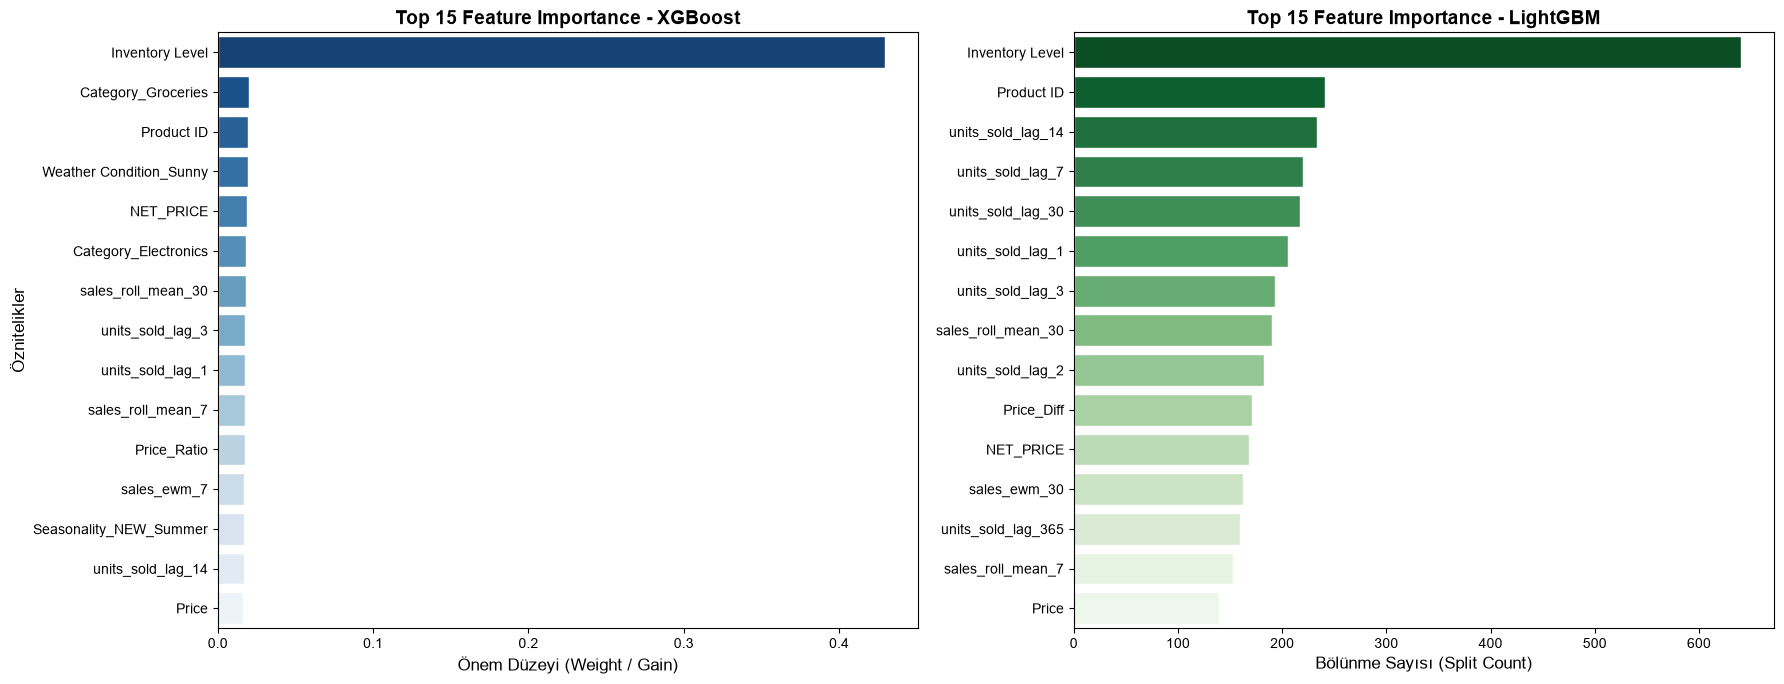

In [40]:
import seaborn as sns

def plot_comparative_importance(xgb_mod, lgbm_mod, feature_names, top_n=15):
    xgb_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_mod.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(top_n)

    lgbm_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": lgbm_mod.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
    sns.set_theme(style="whitegrid")

    # XGBoost
    sns.barplot(
        x="Importance", 
        y="Feature", 
        hue="Feature", 
        data=xgb_df, 
        ax=axes[0], 
        palette="Blues_r", 
        legend=False
    )
    axes[0].set_title(f"Top {top_n} Feature Importance - XGBoost", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Önem Düzeyi (Weight / Gain)", fontsize=12)
    axes[0].set_ylabel("Öznitelikler", fontsize=12)

    # LightGBM
    sns.barplot(
        x="Importance", 
        y="Feature", 
        hue="Feature", 
        data=lgbm_df, 
        ax=axes[1], 
        palette="Greens_r", 
        legend=False
    )
    axes[1].set_title(f"Top {top_n} Feature Importance - LightGBM", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Bölünme Sayısı (Split Count)", fontsize=12)
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

# Fonksiyonu çağırma
plot_comparative_importance(xgb_model, lgbm_model, X_tr.columns, top_n=15)

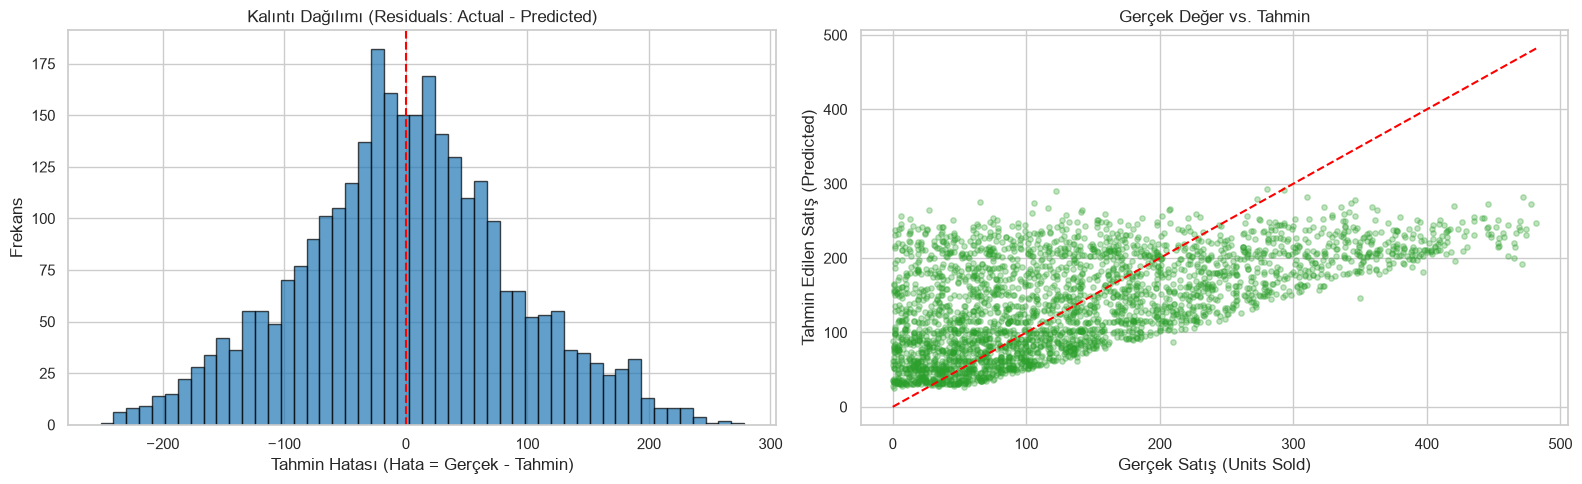

In [41]:
# Hata / Kalıntı Analizi (En iyi model olan LightGBM üzerinden)
residuals = y_val - lgbm_val_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Kalıntıların Dağılımı (Histogram)
axes[0].hist(residuals, bins=50, color="#1f77b4", edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Kalıntı Dağılımı (Residuals: Actual - Predicted)")
axes[0].set_xlabel("Tahmin Hatası (Hata = Gerçek - Tahmin)")
axes[0].set_ylabel("Frekans")

# 2. Gerçek Değer vs. Tahmin Edilen Değer (Scatter)
axes[1].scatter(y_val, lgbm_val_pred, alpha=0.3, color="#2ca02c", s=15)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="red", linestyle="--", lw=1.5)
axes[1].set_title("Gerçek Değer vs. Tahmin")
axes[1].set_xlabel("Gerçek Satış (Units Sold)")
axes[1].set_ylabel("Tahmin Edilen Satış (Predicted)")

plt.tight_layout()
plt.show()

In [ ]:
#Hyperparameter Tuning

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 1. Zaman serisi cross-validation ayrımı
tscv = TimeSeriesSplit(n_splits=3)

# 2. Aranacak parametre ızgarası
lgbm_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [15, 31, 63],
    "colsample_bytree": [0.7, 0.8],
    "subsample": [0.8],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [0.0, 1.0]
}

base_lgbm = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# 3. GridSearchCV
lgbm_grid_search = GridSearchCV(
    estimator=base_lgbm,
    param_grid=lgbm_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

lgbm_grid_search.fit(X_tr, y_tr)

print("En İyi Parametreler:", lgbm_grid_search.best_params_)
print("En İyi CV MAE Skoru:", -lgbm_grid_search.best_score_)

# 4. En iyi modelle validation değerlendirmesi
best_lgbm_model = lgbm_grid_search.best_estimator_
best_lgbm_val_pred = best_lgbm_model.predict(X_val)
best_lgbm_val_results = evaluate_model(y_val, best_lgbm_val_pred)

print("\nTuned LightGBM Validation Sonuçları:")
print(best_lgbm_val_results)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
